# $\color{orange}{\text{C004220A - Statistische fysica}}$ 
# $\color{orange}{\text{Oefeningen: Reeks 1; Oefening 4}}$

Jan Ryckebusch, 2017, 2022

Importeer externe software bibliotheken, bijvoorbeeld om snel operaties te doen op matrices en vectoren (numpy) of om figuren te maken (matplotlib).

In [1]:
# 
#  
import numpy as np   # numerical python: very fast computing
import matplotlib.pyplot as plt # matplotlib: nice & quick figures

Definieer parameters van het probleem, in dit geval een lijst van mogelijke energiewaarden en hun ontaardingen

In [2]:
# list of energy eigenvalues and corresponding degeneracies  
elist = [1., 2. , +3.] # list of possible \alpha 
glist1= [1,2,1] # list of degeneracies (list 1)
glist2= [1,1,1] # list of degeneracies (list 2)

Definieer een functie die, gegeven een set temperaturen (`xvalues`) en de details van het probleem (hierboven gedefinieerd), voor elke temperatuur de gemiddelde energie, de warmtecapaciteit en de entropie berekent.

In [3]:
# function that computes the partition function,
#    ,the average energy, the entropy and specific heat
# x = \alpha / k T (dimensionless quantity)
def create_the_obser(xvalues, elist, glist):
    Z1=np.zeros_like(xvalues) # partition function = dimensionless
    E1=np.zeros_like(xvalues) 
    E2=np.zeros_like(xvalues) # energy^2 in units \alpha^2
    ener=np.zeros_like(xvalues) # energy in units \alpha
    CV=np.zeros_like(xvalues) #  CV = specific heat / k 
    entrop=np.zeros_like(xvalues)
    for m in range(len(elist)):
        Z1+=glist[m]*np.exp(-xvalues*elist[m])
        E1+=glist[m]*elist[m]*np.exp(-xvalues*elist[m])
        E2+=glist[m]*(elist[m]**2)*np.exp(-xvalues*elist[m])
    ener=np.divide(E1,Z1)
    CV=np.divide(E2,Z1)-np.power(ener,2)
    CV=np.multiply(np.power(xvalues,2),CV) # specific heat / k    
# S = (E-F) / T  ; S/k = E / (k T) + log Z 
# E is in units \alpha
# S (in units k) = log Z + x E 
    entrop=np.add(np.log(Z1),np.multiply(xvalues,ener))
    return ener,CV,entrop 

Voer de functie uit. Hiervoor wordt een set van temperaturen gegenereerd en de bovenstaande functie opgeroepen.

In [4]:
# MAIN PROGRAM
# xvalues: an Numpy array with x = (\alpha / k T) values
number_of_xvalues=1000
xvalues=np.linspace(0.,+10.,number_of_xvalues,endpoint=True)
# create the list of observables (energy, specific heat, entropy)
ener1,cv1,entrop1=create_the_obser(xvalues,elist,glist1)
ener2,cv2,entrop2=create_the_obser(xvalues,elist,glist2)

Genereer de figuren: de energie in functie van de dimensieloze grootheid $x = \frac{\alpha}{kT}$, de warmtecapaciteit in functie van $x$ en de entropie in functie van $\frac{1}{x}$.

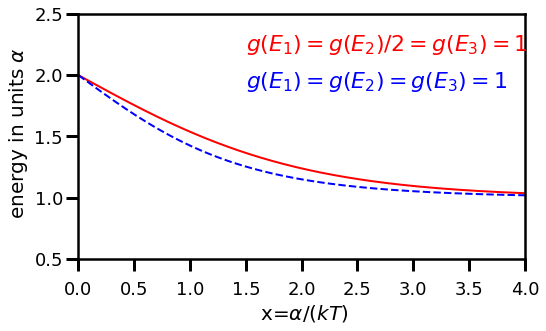

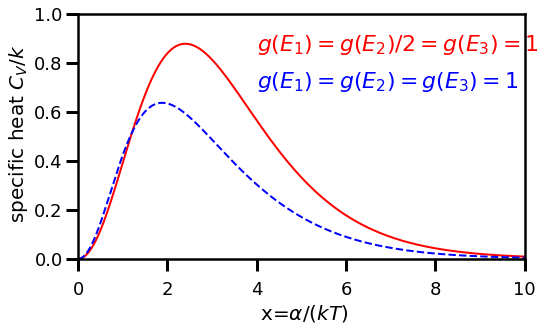

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:60: RuntimeWarning: divide by zero encountered in true_divide


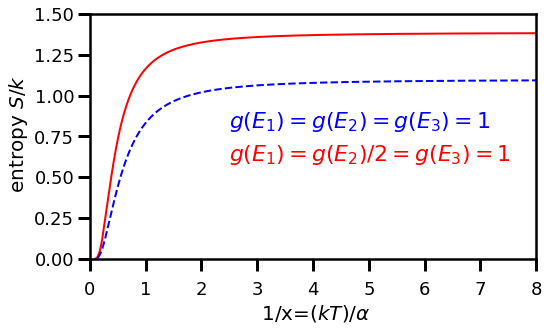

In [8]:
# create the plots in matplotlib
#----------------------------------------------------------------------
# tweak the parameters of the plots ...
# nothing essential, makes things look nicer ...
params = {'legend.fontsize' : 20,
#          'legend.linewidth': 2, TROUBLESOME
          'axes.linewidth'  : 2.5,
          'axes.labelsize'  : 20,
          'lines.linewidth' : 2, 
          'xtick.major.width' : 3,
          'xtick.major.size'  : 12,
          'ytick.major.width' : 3,
          'ytick.major.size'  : 12,
          'xtick.major.pad'  : 10,
          'xtick.minor.width' : 2,
          'xtick.minor.size'  : 6,
          'ytick.minor.width' : 2,
          'ytick.minor.size'  : 6,
          'xtick.labelsize'    : 18,
          'ytick.labelsize'    : 18 }
plt.rcParams.update(params)
#----------------------------------------------------------------------
# first figure: the energy as function of x
fig=plt.figure(1,figsize=(8,5))
ax=fig.add_subplot(111)
fig.subplots_adjust(bottom=0.2) # create room for x-axis label
ax.axis([0.,4.,0.5,2.5])
ax.set_xlabel(r' x=$\alpha / (k T )$')
ax.set_ylabel(r' energy in units $\alpha$')
ax.plot(xvalues, ener1, 'r-', xvalues, ener2, 'b--')
ax.text(1.5, 2.2,r'$g(E_1)=g(E_2)/2=g(E_3)=1$',color='red',fontsize=22,fontweight='bold')
ax.text(1.5, 1.9,r'$g(E_1)=g(E_2)=g(E_3)=1$',color='blue',fontsize=22,fontweight='bold')
fig.savefig('Reeks1Oef4Energy.eps')
fig.savefig('Reeks1Oef4Energy.png')
plt.show(fig)
print("\n","\n")

# second figure with specific heat
fig2=plt.figure(2,figsize=(8,5))
ax2=fig2.add_subplot(111)
fig2.subplots_adjust(bottom=0.2) # create room for x-axis label
ax2.axis([0.,10.,0.,1.])
ax2.set_xlabel(r' x=$\alpha / (k T)$')
ax2.set_ylabel(r' specific heat $ C_V / k  $')
ax2.plot(xvalues, cv1, 'r-', xvalues, cv2, 'b--')
ax2.text(4.0, 0.85,r'$g(E_1)=g(E_2)/2=g(E_3)=1$',color='red',fontsize=22,fontweight='bold')
ax2.text(4.0, 0.70,r'$g(E_1)=g(E_2)=g(E_3)=1$',color='blue',fontsize=22,fontweight='bold')
fig2.savefig('Reeks1Oef4CV.eps')
fig2.savefig('Reeks1Oef4CV.png')
plt.show(fig2)
print("\n","\n")

# third figure with entropy as a function of 1/x
fig3=plt.figure(3,figsize=(8,5))
ax3=fig3.add_subplot(111)
fig3.subplots_adjust(bottom=0.2) # create room for x-axis label
ax3.axis([0.,8.,0.,1.5])
ax3.set_xlabel(r' 1/x=$(k T ) / \alpha $')
ax3.set_ylabel(r' entropy $S /k $ ')
ax3.plot(1./xvalues, entrop1, 'r-', 1./xvalues, entrop2,'b--')
ax3.text(2.5, 0.6,r'$g(E_1)=g(E_2)/2=g(E_3)=1$',color='red',fontsize=22,fontweight='bold')
ax3.text(2.5, 0.8,r'$g(E_1)=g(E_2)=g(E_3)=1$',color='blue',fontsize=22,fontweight='bold')
fig3.savefig('Reeks1Oef4Entropy.eps')
fig3.savefig('Reeks1Oef4Entropy.png')
plt.show(fig3)
print("\n","\n")
